In [ ]:
!pip install pyDOE2 tqdm
!pip install smt

In [ ]:
import os
base_dir = "results"
os.makedirs(base_dir, exist_ok=True)
adam_dir = os.path.join(base_dir, "adam")
stridge_dir = os.path.join(base_dir, "stridge")
general_dir = os.path.join(base_dir, "general")
os.makedirs(adam_dir, exist_ok=True)
os.makedirs(stridge_dir, exist_ok=True)
os.makedirs(general_dir, exist_ok=True)

In [ ]:
!rm -rf '/content/results'

Device mapping:
/job:localhost/replica:0/task:0/device:GPU:0 -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:00:04.0, compute capability: 8.0

Adam begins
It: 0, Log Loss: -2.569e+00, loss_u: 7.648036e-02, loss_f: 1.283834e-04, loss_lambda: 0.000000e+00, Time: 0.81
It: 10, Log Loss: -2.698e+00, loss_u: 6.722458e-02, loss_f: 9.089748e-05, loss_lambda: 0.000000e+00, Time: 0.16
It: 20, Log Loss: -2.780e+00, loss_u: 6.192527e-02, loss_f: 1.225418e-04, loss_lambda: 0.000000e+00, Time: 0.14
It: 30, Log Loss: -2.859e+00, loss_u: 5.710522e-02, loss_f: 2.257877e-04, loss_lambda: 0.000000e+00, Time: 0.14
It: 40, Log Loss: -2.936e+00, loss_u: 5.271438e-02, loss_f: 3.446579e-04, loss_lambda: 0.000000e+00, Time: 0.14
It: 50, Log Loss: -2.994e+00, loss_u: 4.964399e-02, loss_f: 4.429001e-04, loss_lambda: 0.000000e+00, Time: 0.14
It: 60, Log Loss: -2.999e+00, loss_u: 4.932632e-02, loss_f: 4.887662e-04, loss_lambda: 0.000000e+00, Time: 0.14
It: 70, Log Loss: -2.955e+00, loss_u: 5.160131e-02

/tmp/ipykernel_25297/2660460796.py:866: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f.write('lambda5_error: %.2f%% \n' % (lambda5_error))
/tmp/ipykernel_25297/2660460796.py:867: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f.write('lambda8_error: %.2f%% \n' % (lambda8_error))


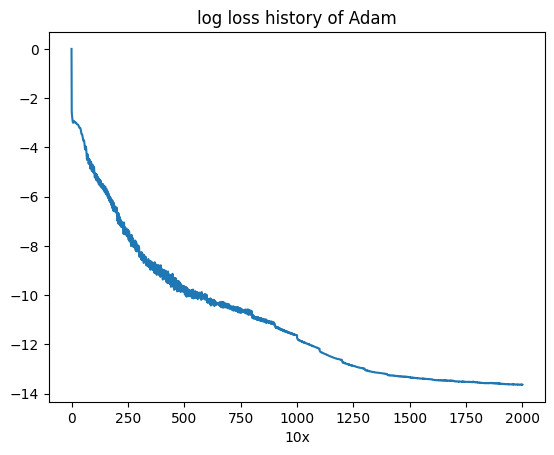

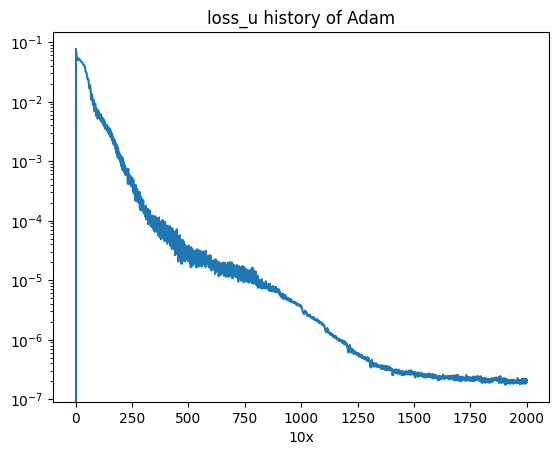

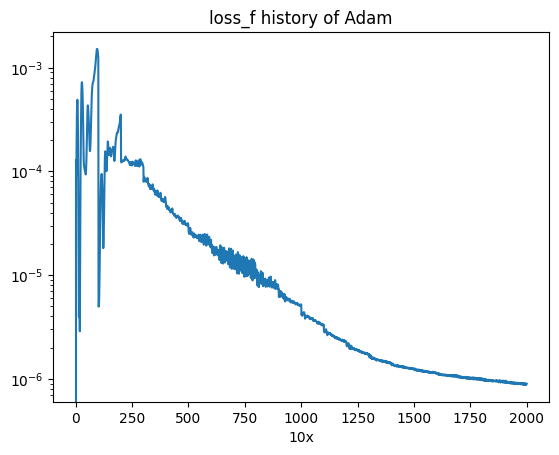

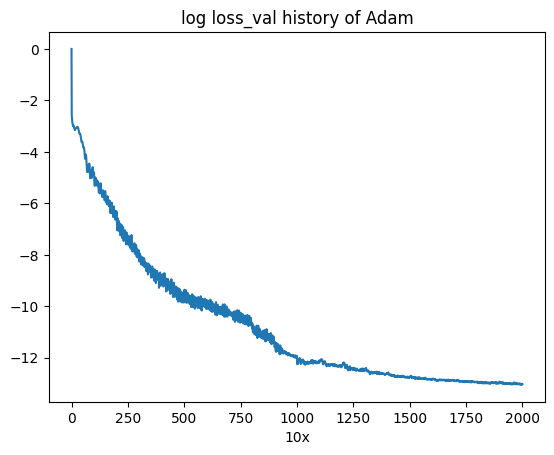

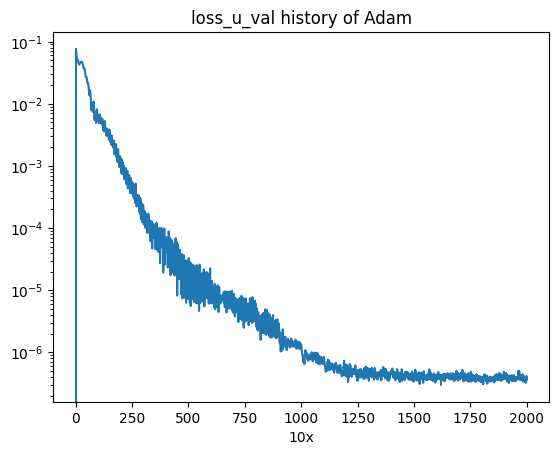

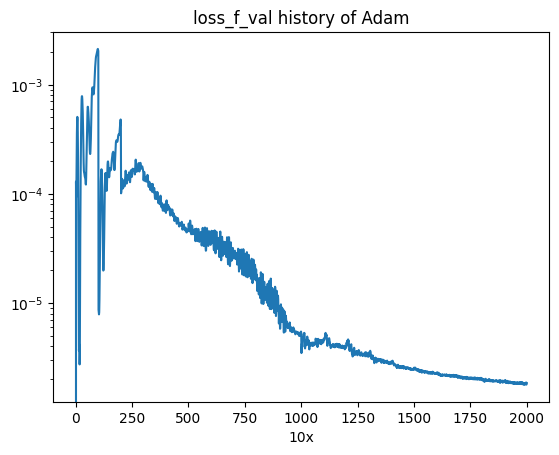

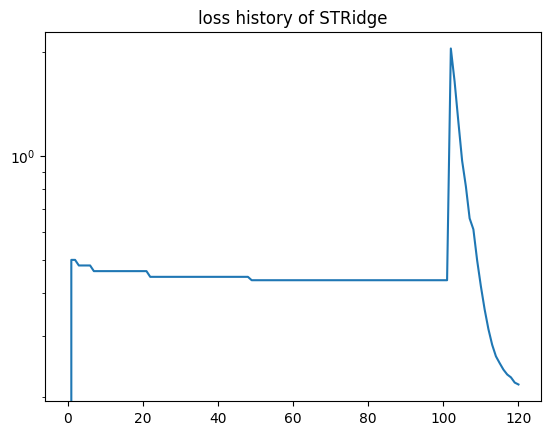

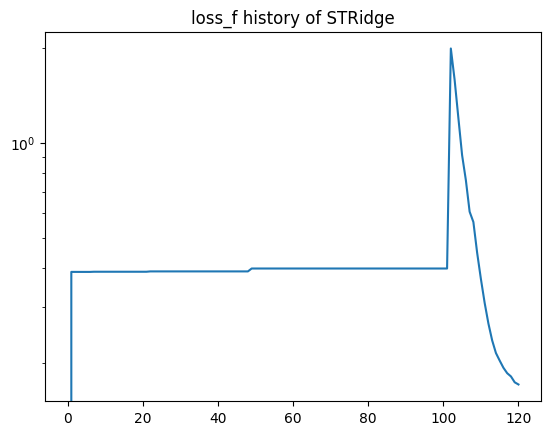

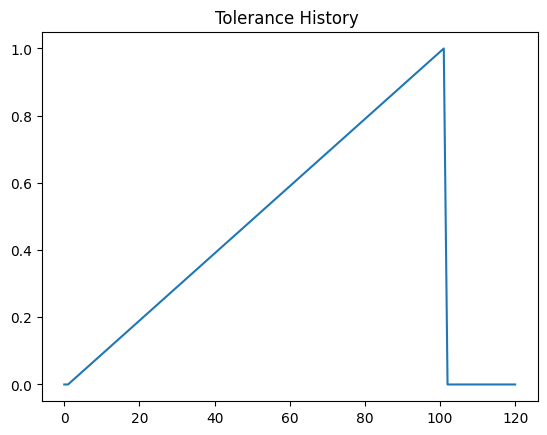

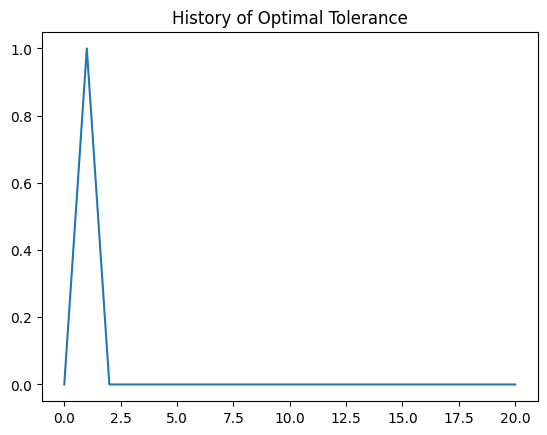

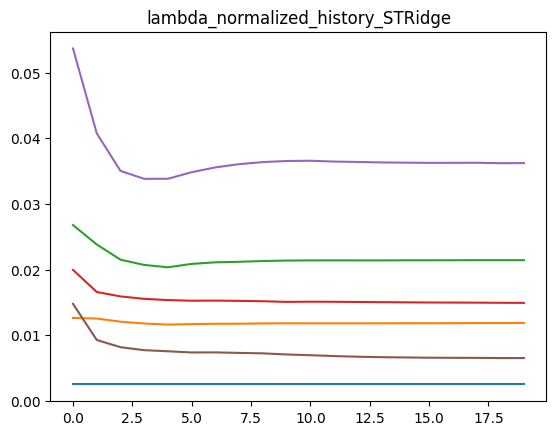

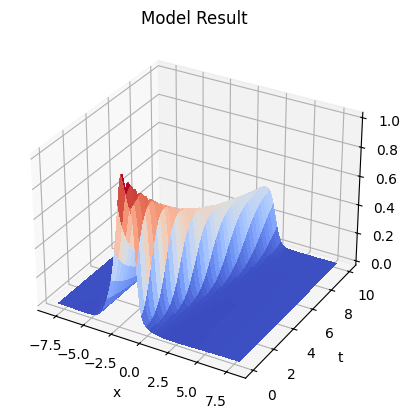

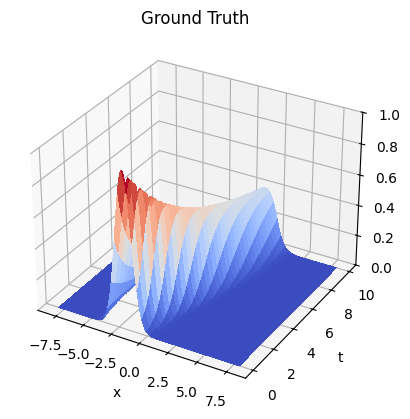

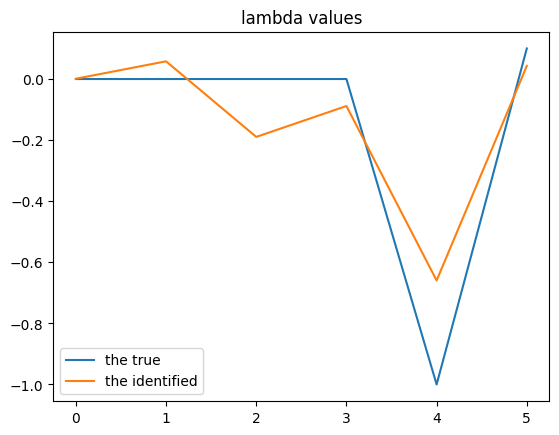

In [ ]:
# =============================================================================
# Physics-informed learning of governing equations from scarce data
# Zhao Chen, Yang Liu, and Hao Sun
# 2021. Northeastern University
# =============================================================================
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

with tf.device('/device:GPU:0'):

    import numpy as np
    import matplotlib.pyplot as plt
    import scipy.io
    from scipy.interpolate import griddata
    from scipy.spatial import distance
    from matplotlib import cm
    import time
    from mpl_toolkits.mplot3d import Axes3D
    from smt.sampling_methods import LHS
    def lhs(dim, samples):
        xlimits = np.array([[0.0, 1.0]] * dim)
        sampling = LHS(xlimits=xlimits)
        return sampling(samples)
#    import sobol_seq

# =============================================================================
#  define loss histories to record convergence
# =============================================================================
    # L-BFGS-S loss history
    loss_history = np.array([0])
    loss_u_history = np.array([0])
    loss_f_history = np.array([0])
    loss_lambda_history = np.array([0])
    loss_history_val = np.array([0])
    loss_u_history_val = np.array([0])
    loss_f_history_val = np.array([0])
    step = 0

    # Adam loss history
    loss_history_Adam = np.array([0])
    loss_u_history_Adam = np.array([0])
    loss_f_history_Adam = np.array([0])
    loss_lambda_history_Adam = np.array([0])
    lambda_history_Adam = np.zeros((6,1))
    loss_history_Adam_val = np.array([0])
    loss_u_history_Adam_val = np.array([0])
    loss_f_history_Adam_val = np.array([0])

    # STRidge loss history
    loss_history_STRidge = np.array([0])
    loss_f_history_STRidge = np.array([0])
    loss_lambda_history_STRidge = np.array([0])
    optimaltol_history = np.array([0])
    tol_history_STRidge = np.array([0])
    lambda_normalized_history_STRidge = np.zeros((6,1))


    # Loss histories for pretraining
    loss_history_Pretrain = np.array([0])
    loss_u_history_Pretrain = np.array([0])
    loss_f_history_Pretrain = np.array([0])
    loss_lambda_history_Pretrain = np.array([0])
    loss_history_val_Pretrain = np.array([0])
    loss_u_history_val_Pretrain = np.array([0])
    loss_f_history_val_Pretrain = np.array([0])
    step_Pretrain = 0

    np.random.seed(1234)
    tf.set_random_seed(1234)

    class PhysicsInformedNN:
# =============================================================================
#     Inspired by Raissi, Maziar, Paris Perdikaris, and George E. Karniadakis.
#     "Physics-informed neural networks: A deep learning framework for solving forward and inverse problems
#     involving nonlinear partial differential equations." Journal of Computational Physics 378 (2019): 686-707.
# =============================================================================
        # Initialize the class
        def __init__(self, X, u, X_f, X_val, u_val, layers, lb, ub):

            self.lb = lb
            self.ub = ub
            self.layers = layers

            # Initialize NNs
            self.weights, self.biases = self.initialize_NN(layers)

            config=tf.ConfigProto(allow_soft_placement=True, log_device_placement=True)
            config.gpu_options.allow_growth = True
            self.sess = tf.Session(config = config)

            # Initialize parameters
            self.lambda1 = tf.Variable(tf.zeros([6, 1], dtype=tf.float32), dtype=tf.float32, name = 'lambda')

            # Specify the list of trainable variables
            var_list_1 = self.biases + self.weights
            # var_list_1 = self.biases + self.weights + [self.lambda1]

            var_list_Pretrain = self.biases + self.weights
            var_list_Pretrain.append(self.lambda1)

            ######### Training data ################
            self.x = X[:,0:1]
            self.t = X[:,1:2]
            self.u = u
            self.x_f = X_f[:, 0:1]
            self.t_f = X_f[:, 1:2]

            self.x_tf = tf.placeholder(tf.float32, shape=[None, self.x.shape[1]])
            self.t_tf = tf.placeholder(tf.float32, shape=[None, self.t.shape[1]])
            self.u_tf = tf.placeholder(tf.float32, shape=[None, self.u.shape[1]])
            self.x_f_tf = tf.placeholder(tf.float32, shape=[None, self.x_f.shape[1]])
            self.t_f_tf = tf.placeholder(tf.float32, shape=[None, self.t_f.shape[1]])

            self.u_pred = self.net_u(self.x_tf, self.t_tf)
            self.f_pred, self.Phi_pred, self.u_t_pred = self.net_f(self.x_f_tf, self.t_f_tf, self.x_f.shape[0])

            self.loss_u = tf.reduce_mean(tf.square(self.u_tf - self.u_pred))
            self.loss_f = tf.reduce_mean(tf.square(self.f_pred))

            self.loss_lambda = 1e-07*tf.norm(self.lambda1, ord = 1)

            self.loss = tf.log(self.loss_u  + self.loss_f + self.loss_lambda) # log loss

            ######### Validation data ################
            self.x_val = X_val[:,0:1]
            self.t_val = X_val[:,1:2]
            self.u_val = u_val

            self.x_val_tf = tf.placeholder(tf.float32, shape=[None, self.x_val.shape[1]])
            self.t_val_tf = tf.placeholder(tf.float32, shape=[None, self.t_val.shape[1]])
            self.u_val_tf = tf.placeholder(tf.float32, shape=[None, self.u_val.shape[1]])

            self.u_val_pred = self.net_u(self.x_val_tf, self.t_val_tf)
            self.f_val_pred, _, _ = self.net_f(self.x_val_tf, self.t_val_tf, self.x_val.shape[0])

            self.loss_u_val = tf.reduce_mean(tf.square(self.u_val_tf - self.u_val_pred))
            self.loss_f_val = tf.reduce_mean(tf.square(self.f_val_pred))
            self.loss_val = tf.log(self.loss_u_val  + self.loss_f_val) # log loss

            ######### Optimizor #########################
            # self.optimizer = tf.contrib.opt.ScipyOptimizerInterface(self.loss,
            #                                                         var_list = var_list_1,
            #                                                         method = 'L-BFGS-B',
            #                                                         options = {'maxiter': 1000,
            #                                                                    'maxfun': 1000,
            #                                                                    'maxcor': 50,
            #                                                                    'maxls': 50,
            #                                                                    'ftol' : 1.0 * np.finfo(float).eps})

            # self.optimizer_Pretrain = tf.contrib.opt.ScipyOptimizerInterface(self.loss,
            #                                                         var_list = var_list_Pretrain,
            #                                                         method = 'L-BFGS-B',
            #                                                        options = {'maxiter': 1000,
            #                                                                    'maxfun': 1000,
            #                                                                    'maxcor': 50,
            #                                                                    'maxls': 50,
            #                                                                    'ftol' : 1.0 * np.finfo(float).eps})

            # The default settings: learning rate = 1e-3, beta1 = 0.9, beta2 = 0.999， epsilon = 1e-8
            self.optimizer_Adam = tf.train.AdamOptimizer(learning_rate=1e-4, beta1 = 0.99, beta2 = 0.9, epsilon = 1e-8)
            self.train_op_Adam = self.optimizer_Adam.minimize(self.loss, var_list = var_list_1)
            self.tf_dict = {self.x_tf: self.x, self.t_tf: self.t, self.u_tf: self.u,
                       self.x_f_tf: self.x_f, self.t_f_tf: self.t_f,
                       self.x_val_tf: self.x_val, self.t_val_tf: self.t_val, self.u_val_tf: self.u_val}

            init = tf.global_variables_initializer()
            self.sess.run(init)

        def initialize_NN(self, layers):
            weights = []
            biases = []
            num_layers = len(layers)
            for l in range(0,num_layers-1):
                W = self.xavier_init(size=[layers[l], layers[l+1]])
                b = tf.Variable(tf.zeros([1,layers[l+1]], dtype=tf.float32), dtype=tf.float32, name = 'b')
                weights.append(W)
                biases.append(b)
            return weights, biases

        def xavier_init(self, size):
            in_dim = size[0]
            out_dim = size[1]
            xavier_stddev = np.sqrt(2/(in_dim + out_dim))
            return tf.Variable(tf.truncated_normal([in_dim, out_dim], stddev=xavier_stddev), dtype=tf.float32, name = 'W')

        def neural_net(self, X, weights, biases):
            num_layers = len(weights) + 1

            H = 2.0*(X - self.lb)/(self.ub - self.lb) - 1.0
            for l in range(0,num_layers-2):
                W = weights[l]
                b = biases[l]
                H = tf.tanh(tf.add(tf.matmul(H, W), b))
            W = weights[-1]
            b = biases[-1]
            Y = tf.add(tf.matmul(H, W), b)
            return Y

        def net_u(self, x, t):
            u = self.neural_net(tf.concat([x,t],1), self.weights, self.biases)
            return u

        def net_f(self, x, t, N_f):
            u = self.net_u(x,t)
            u_t = tf.gradients(u, t)[0]
            u_x = tf.gradients(u, x)[0]
            u_xx = tf.gradients(u_x, x)[0]
            # u_xxx = tf.gradients(u_xx, x)[0]
            # Phi = tf.concat([tf.constant(1, shape=[N_f, 1], dtype=tf.float32), u, u**2, u**3, u_x, u*u_x, u**2*u_x,
            #                       u**3*u_x, u_xx, u*u_xx, u**2*u_xx, u**3*u_xx, u_xxx, u*u_xxx, u**2*u_xxx, u**3*u_xxx], 1)
            # self.library_description = ['1',
            #              'u', 'u**2', 'u**3',
            #              'u_x', 'u*u_x', 'u**2*u_x', 'u**3*u_x',
            #              'u_xx', 'u*u_xx', 'u**2*u_xx', 'u**3*u_xx',
            #              'u_xxx', 'u*u_xxx', 'u**2*u_xxx', 'u**3*u_xxx']
            Phi = tf.concat([
                tf.constant(1, shape=[N_f, 1], dtype=tf.float32),
                u,
                u**2,
                u_x,
                u*u_x,
                u_xx
            ], 1)

            self.library_description = [
                '1',
                'u',
                'u**2',
                'u_x',
                'u*u_x',
                'u_xx'
            ]
            f = tf.matmul(Phi, self.lambda1) - u_t
            return f, Phi, u_t

        def callback(self, loss, loss_u, loss_f, loss_lambda, loss_val, loss_u_val, loss_f_val):
            global step
            step = step+1
            if step%10 == 0:
                print('Step: %d, log Loss: %e, loss_u: %e, loss_f: %e, loss_lambda: %e' % (step, loss, loss_u, loss_f, loss_lambda))

                global loss_history
                global loss_u_history
                global loss_f_history
                global loss_lambda_history

                global loss_history_val
                global loss_u_history_val
                global loss_f_history_val

                loss_history = np.append(loss_history, loss)
                loss_u_history = np.append(loss_u_history, loss_u)
                loss_f_history = np.append(loss_f_history, loss_f)
                loss_lambda_history = np.append(loss_lambda_history, loss_lambda)

                loss_history_val = np.append(loss_history_val, loss_val)
                loss_u_history_val = np.append(loss_u_history_val, loss_u_val)
                loss_f_history_val = np.append(loss_f_history_val, loss_f_val)

        def callback_Pretrain(self, loss, loss_u, loss_f, loss_lambda, loss_val, loss_u_val, loss_f_val):
            global step_Pretrain
            step_Pretrain += 1
            if step_Pretrain % 10 == 0:
                print('Step: %d, log Loss: %e, loss_u: %e, loss_f: %e, loss_lambda: %e' % (step_Pretrain, loss, loss_u, loss_f,
                                                                                           loss_lambda))

                global loss_history_Pretrain
                global loss_u_history_Pretrain
                global loss_f_history_Pretrain
                global loss_lambda_history_Pretrain

                global loss_history_val_Pretrain
                global loss_u_history_val_Pretrain
                global loss_f_history_val_Pretrain

                loss_history_Pretrain = np.append(loss_history_Pretrain, loss)
                loss_u_history_Pretrain = np.append(loss_u_history_Pretrain, loss_u)
                loss_f_history_Pretrain = np.append(loss_f_history_Pretrain, loss_f)
                loss_lambda_history_Pretrain = np.append(loss_lambda_history_Pretrain, loss_lambda)

                loss_history_val_Pretrain = np.append(loss_history_val_Pretrain, loss_val)
                loss_u_history_val_Pretrain = np.append(loss_u_history_val_Pretrain, loss_u_val)
                loss_f_history_val_Pretrain = np.append(loss_f_history_val_Pretrain, loss_f_val)

        def train(self, nIter): # nIter is the number of ADO loop
            tf_dict = {self.x_tf: self.x, self.t_tf: self.t, self.u_tf: self.u,
                       self.x_f_tf: self.x_f, self.t_f_tf: self.t_f,
                       self.x_val_tf: self.x_val, self.t_val_tf: self.t_val, self.u_val_tf: self.u_val}

            # Pretraining,as a form of a good intialization
            # print('L-BFGS-B pretraining begins')
            # self.optimizer_Pretrain.minimize(self.sess,
            #                         feed_dict = tf_dict,
            #                         fetches = [self.loss, self.loss_u, self.loss_f, self.loss_lambda,
            #                                    self.loss_val, self.loss_u_val, self.loss_f_val],
            #                         loss_callback = self.callback_Pretrain)

            for it in range(nIter):

                # Loop of Adam optimization
                print('Adam begins')
                start_time = time.time()
                for it_Adam in range(1000):

                    self.sess.run(self.train_op_Adam, tf_dict)

                    # Print
                    if it_Adam % 10 == 0:
                        elapsed = time.time() - start_time
                        loss, loss_u, loss_f, loss_lambda, lambda1_value, loss_val, loss_u_val, loss_f_val = self.sess.run([self.loss, self.loss_u, self.loss_f, self.loss_lambda, self.lambda1, self.loss_val, self.loss_u_val, self.loss_f_val], tf_dict)
                        print('It: %d, Log Loss: %.3e, loss_u: %e, loss_f: %e, loss_lambda: %e, Time: %.2f'
                              % (it_Adam, loss, loss_u, loss_f, loss_lambda, elapsed))

                        global loss_history_Adam
                        global lambda_history_Adam
                        global loss_u_history_Adam
                        global loss_f_history_Adam
                        global loss_lambda_history_Adam

                        global loss_history_Adam_val
                        global loss_u_history_Adam_val
                        global loss_f_history_Adam_val

                        loss_history_Adam = np.append(loss_history_Adam, loss)
                        lambda_history_Adam = np.append(lambda_history_Adam, lambda1_value, axis=1)
                        loss_u_history_Adam = np.append(loss_u_history_Adam, loss_u)
                        loss_f_history_Adam = np.append(loss_f_history_Adam, loss_f)
                        loss_lambda_history_Adam = np.append(loss_lambda_history_Adam, loss_lambda)

                        loss_history_Adam_val = np.append(loss_history_Adam_val, loss_val)
                        loss_u_history_Adam_val = np.append(loss_u_history_Adam_val, loss_u_val)
                        loss_f_history_Adam_val = np.append(loss_f_history_Adam_val, loss_f_val)

                        start_time = time.time()

                # Loop of L-BFGS-B optimization
                # print('L-BFGS-B begins')
                # self.optimizer.minimize(self.sess,
                #                         feed_dict = tf_dict,
                #                         fetches = [self.loss, self.loss_u, self.loss_f, self.loss_lambda,
                #                                    self.loss_val, self.loss_u_val, self.loss_f_val],
                #                         loss_callback = self.callback)

                # Loop of STRidge optimization
                print('STRidge begins')
                self.callTrainSTRidge()


        def predict(self, X_star):

            tf_dict = {self.x_tf: X_star[:,0:1], self.t_tf: X_star[:,1:2]}

            u_star = self.sess.run(self.u_pred, tf_dict)

            return u_star

        def callTrainSTRidge(self):
            lam = 1e-5
            d_tol = 0.01
            maxit = 100
            STR_iters = 10

            l0_penalty = None

            normalize = 2
            split = 0.8
            print_best_tol = False
            Phi_pred, u_t_pred = self.sess.run([self.Phi_pred, self.u_t_pred], self.tf_dict)

            lambda2 = self.TrainSTRidge(Phi_pred, u_t_pred, lam, d_tol, maxit, STR_iters, l0_penalty, normalize, split,
                                             print_best_tol)

            # self.lambda1 = tf.assign(self.lambda1, tf.convert_to_tensor(lambda2, dtype = tf.float32))
            assign_op = tf.assign(self.lambda1, tf.convert_to_tensor(lambda2, dtype=tf.float32))
            self.sess.run(assign_op)
            print("Updated lambda:")
            print(lambda2.flatten())

        def TrainSTRidge(self, R0, Ut, lam, d_tol, maxit, STR_iters = 10, l0_penalty = None, normalize = 2, split = 0.8,
                         print_best_tol = False):
# =============================================================================
#        Inspired by Rudy, Samuel H., et al. "Data-driven discovery of partial differential equations."
#        Science Advances 3.4 (2017): e1602614.
# =============================================================================
            # First normalize data
            n,d = R0.shape
            R = np.zeros((n,d), dtype=np.float32)
            if normalize != 0:
                Mreg = np.zeros((d,1))
                for i in range(0,d):
                    Mreg[i] = 1.0/(np.linalg.norm(R0[:,i],normalize))
                    R[:,i] = Mreg[i]*R0[:,i]
                normalize_inner = 0
            else:
                R = R0
                Mreg = np.ones((d,1))*d
                normalize_inner = 2


            global lambda_normalized_history_STRidge
            lambda_normalized_history_STRidge = np.append(lambda_normalized_history_STRidge, Mreg, axis = 1)

            # Split data into 80% training and 20% test, then search for the best tolderance.
            np.random.seed(0) # for consistancy
            n,_ = R.shape
            train = np.random.choice(n, int(n*split), replace = False)
            test = [i for i in np.arange(n) if i not in train]
            TrainR = R[train,:]
            TestR = R[test,:]
            TrainY = Ut[train,:]
            TestY = Ut[test,:]

            # Set up the initial tolerance and l0 penalty
            d_tol = float(d_tol)
            tol = d_tol
            if l0_penalty == None: l0_penalty = 0.001*np.linalg.cond(R)

            # Or inherit Lambda
            # w_best = self.sess.run(self.lambda1)/Mreg
            # Initial ridge regression estimate
            if lam != 0:
                w_best = np.linalg.lstsq(
                    TrainR.T.dot(TrainR) + lam * np.eye(d),
                    TrainR.T.dot(TrainY),
                    rcond=None
                )[0]
            else:
                w_best = np.linalg.lstsq(TrainR, TrainY, rcond=None)[0]

            err_f = np.linalg.norm(TestY - TestR.dot(w_best), 2)
            err_lambda = l0_penalty*np.count_nonzero(w_best)
            err_best = err_f + err_lambda
            tol_best = 0

            global loss_history_STRidge
            global loss_f_history_STRidge
            global loss_lambda_history_STRidge
            global tol_history_STRidge

            loss_history_STRidge = np.append(loss_history_STRidge, err_best)
            loss_f_history_STRidge = np.append(loss_f_history_STRidge, err_f)
            loss_lambda_history_STRidge = np.append(loss_lambda_history_STRidge, err_lambda)
            tol_history_STRidge = np.append(tol_history_STRidge, tol_best)

            # Now increase tolerance until test performance decreases
            for iter in range(maxit):

                # Get a set of coefficients and error
                w = self.STRidge(TrainR, TrainY, lam, STR_iters, tol, Mreg, normalize = normalize_inner)
                err_f = np.linalg.norm(TestY - TestR.dot(w), 2)
                err_lambda = l0_penalty*np.count_nonzero(w)
                err = err_f + err_lambda

                # Has the accuracy improved?
                if err <= err_best:
                    err_best = err
                    w_best = w
                    tol_best = tol
                    tol = tol + d_tol

                    loss_history_STRidge = np.append(loss_history_STRidge, err_best)
                    loss_f_history_STRidge = np.append(loss_f_history_STRidge, err_f)
                    loss_lambda_history_STRidge = np.append(loss_lambda_history_STRidge, err_lambda)
                    tol_history_STRidge = np.append(tol_history_STRidge, tol_best)

                else:
                    tol = max([0,tol - 2*d_tol])
                    d_tol = d_tol/1.618
                    tol = tol + d_tol

            if print_best_tol: print ("Optimal tolerance:", tol_best)

            global optimaltol_history
            optimaltol_history = np.append(optimaltol_history, tol_best)

            return np.real(np.multiply(Mreg, w_best))

        def STRidge(self, X0, y, lam, maxit, tol, Mreg, normalize = 2, print_results = False):

            n,d = X0.shape
            X = np.zeros((n,d), dtype=np.complex64)
            # First normalize data
            if normalize != 0:
                Mreg = np.zeros((d,1))
                for i in range(0,d):
                    Mreg[i] = 1.0/(np.linalg.norm(X0[:,i],normalize))
                    X[:,i] = Mreg[i]*X0[:,i]
            else:
                X = X0

            # Inherit lambda
            # w = self.sess.run(self.lambda1)/Mreg
            # Initial ridge regression estimate instead of inheriting zero lambda
            if lam != 0:
                w = np.linalg.lstsq(
                    X.T.dot(X) + lam * np.eye(d),
                    X.T.dot(y),
                    rcond=None
                )[0]
            else:
                w = np.linalg.lstsq(X, y, rcond=None)[0]

            biginds = np.where(abs(w) > tol)[0]
            num_relevant = d

            # Threshold and continue
            for j in range(maxit):

                # Figure out which items to cut out
                smallinds = np.where(abs(w) < tol)[0]
                new_biginds = [i for i in range(d) if i not in smallinds]

                # If nothing changes then stop
                if num_relevant == len(new_biginds): break
                else: num_relevant = len(new_biginds)

                if len(new_biginds) == 0:
                    if j == 0:
                        if normalize != 0:
                            return np.multiply(Mreg, w)
                        else:
                            return w
                    else: break
                biginds = new_biginds

                # Otherwise get a new guess
                w[smallinds] = 0

                if lam != 0: w[biginds] = np.linalg.lstsq(X[:, biginds].T.dot(X[:, biginds]) + lam*np.eye(len(biginds)),X[:, biginds].T.dot(y))[0]
                else: w[biginds] = np.linalg.lstsq(X[:, biginds],y)[0]

            # Now that we have the sparsity pattern, use standard least squares to get w
            # if biginds != []: w[biginds] = np.linalg.lstsq(X[:, biginds],y)[0]
            if len(biginds) > 0:
                w[biginds] = np.linalg.lstsq(X[:, biginds], y, rcond=None)[0]

            if normalize != 0:
                return np.multiply(Mreg, w)
            else:
                return w

    if __name__ == "__main__":

        start_time = time.time()

        layers = [2, 20, 20, 20, 20, 20, 20, 20, 20, 1]

# =============================================================================
#         load data
# =============================================================================
        data = scipy.io.loadmat('burgers.mat')

        t = np.real(data['t'].flatten()[:,None])
        x = np.real(data['x'].flatten()[:,None])
        Exact = np.real(data['usol']).T

        X, T = np.meshgrid(x,t)

        X_star = np.hstack((X.flatten()[:,None], T.flatten()[:,None]))
        u_star = Exact.flatten()[:,None]

        # Doman bounds
        lb = X_star.min(0)
        ub = X_star.max(0)

        # Measurement data
        # In this case, measurements are from N_u_s points and continuously sampled all the time.
        N_u_s = 5 # Total measurement points are 101*20=2020, about 7.8% of total grid numbers.
        idx_s = np.random.choice(x.shape[0], N_u_s, replace=False)
        X0 = X[:, idx_s]
        T0 = T[:, idx_s]
        Exact0 = Exact[:, idx_s]

        N_u_t = int(t.shape[0]*1)
        idx_t = np.random.choice(t.shape[0], N_u_t, replace=False)
        X0 = X0[idx_t, :]
        T0 = T0[idx_t, :]
        Exact0 = Exact0[idx_t, :]

        X_u_meas = np.hstack((X0.flatten()[:,None], T0.flatten()[:,None]))
        u_meas = Exact0.flatten()[:,None]

        # Training measurements, which are randomly sampled spatio-temporally
        Split_TrainVal = 0.8
        N_u_train = int(X_u_meas.shape[0]*Split_TrainVal)
        idx_train = np.random.choice(X_u_meas.shape[0], N_u_train, replace=False)
        X_u_train = X_u_meas[idx_train,:]
        u_train = u_meas[idx_train,:]

        # Validation Measurements, which are the rest of measurements
        idx_val = np.setdiff1d(np.arange(X_u_meas.shape[0]), idx_train, assume_unique=True)
        X_u_val = X_u_meas[idx_val,:]
        u_val = u_meas[idx_val,:]

        # Collocation points
        N_f = 160000

        X_f_train = lb + (ub-lb)*lhs(2, N_f)
    #    X_f_train = lb + (ub-lb)*sobol_seq.i4_sobol_generate(2, N_f)
        X_f_train = np.vstack((X_f_train, X_u_train))

        # Option: Add noise
        noise = 0.0
        u_train = u_train + noise*np.std(u_train)*np.random.randn(u_train.shape[0], u_train.shape[1])
        u_val = u_val + noise*np.std(u_val)*np.random.randn(u_val.shape[0], u_val.shape[1])

# =============================================================================
#         model
# =============================================================================
        model = PhysicsInformedNN(X_u_train, u_train, X_f_train, X_u_val, u_val, layers, lb, ub)
        model.train(20)

# =============================================================================
#         results & diagnostics
# =============================================================================
        # determine whether the training is sufficient

        f = open(os.path.join(general_dir, "stdout.txt"), "a+")

        u_train_Pred = model.predict(X_u_train)
        Error_u_Train = np.linalg.norm(u_train-u_train_Pred,2)/np.linalg.norm(u_train,2)
        f.write('Training Error u: %e \n' % (Error_u_Train))

        u_val_Pred = model.predict(X_u_val)
        Error_u_Val = np.linalg.norm(u_val-u_val_Pred,2)/np.linalg.norm(u_val,2)
        f.write('Validation Error u: %e \n' % (Error_u_Val))


        elapsed = time.time() - start_time
        f.write('Training time: %.4f \n' % (elapsed))

        ######################## Plots for BFGS(Pretraining) #################
        # fig = plt.figure()
        # plt.plot(loss_history_Pretrain)
        # plt.xlabel('10x')
        # plt.title('log loss history of BFGS(Pretraining)')
        # plt.savefig('1.png')

        # fig = plt.figure()
        # plt.plot(loss_u_history_Pretrain)
        # plt.yscale('log')
        # plt.xlabel('10x')
        # plt.title('loss_u history of BFGS(Pretraining)')
        # plt.savefig('2.png')

        # fig = plt.figure()
        # plt.plot(loss_f_history_Pretrain)
        # plt.yscale('log')
        # plt.xlabel('10x')
        # plt.title('loss_f history of BFGS(Pretraining)')
        # plt.savefig('3.png')

        # fig = plt.figure()
        # plt.plot(loss_lambda_history_Pretrain)
        # plt.yscale('log')
        # plt.xlabel('10x')
        # plt.title('loss_lambda history of BFGS(Pretraining)')
        # plt.savefig('4.png')

        # fig = plt.figure()
        # plt.plot(loss_history_val_Pretrain)
        # plt.xlabel('10x')
        # plt.title('log loss_val history of BFGS(Pretraining)')
        # plt.savefig('5.png')

        # fig = plt.figure()
        # plt.plot(loss_u_history_val_Pretrain)
        # plt.yscale('log')
        # plt.xlabel('10x')
        # plt.title('loss_u_val history of BFGS(Pretraining)')
        # plt.savefig('6.png')

        # fig = plt.figure()
        # plt.plot(loss_f_history_val_Pretrain)
        # plt.yscale('log')
        # plt.xlabel('10x')
        # plt.title('loss_f_val history of BFGS(Pretraining)')
        # plt.savefig('7.png')

        ######################## Plots for Adam #################
        fig = plt.figure()
        plt.plot(loss_history_Adam)
        plt.xlabel('10x')
        plt.title('log loss history of Adam')
        plt.savefig(os.path.join(adam_dir, '8.png'))

        fig = plt.figure()
        plt.plot(loss_u_history_Adam)
        plt.yscale('log')
        plt.xlabel('10x')
        plt.title('loss_u history of Adam')
        plt.savefig(os.path.join(adam_dir, '9.png'))

        fig = plt.figure()
        plt.plot(loss_f_history_Adam)
        plt.yscale('log')
        plt.xlabel('10x')
        plt.title('loss_f history of Adam')
        plt.savefig(os.path.join(adam_dir, '10.png'))

        fig = plt.figure()
        plt.plot(loss_lambda_history_Adam + 1e-20)
        if np.any(loss_lambda_history_Adam > 0):
            plt.yscale('log')
        plt.xlabel('10x')
        plt.title('loss_lambda history of Adam')
        plt.savefig(os.path.join(adam_dir, '11.png'))
        plt.close(fig)

        fig = plt.figure()
        plt.plot(loss_history_Adam_val)
        plt.xlabel('10x')
        plt.title('log loss_val history of Adam')
        plt.savefig(os.path.join(adam_dir, '12.png'))

        fig = plt.figure()
        plt.plot(loss_u_history_Adam_val)
        plt.yscale('log')
        plt.xlabel('10x')
        plt.title('loss_u_val history of Adam')
        plt.savefig(os.path.join(adam_dir, '13.png'))

        fig = plt.figure()
        plt.plot(loss_f_history_Adam_val)
        plt.yscale('log')
        plt.xlabel('10x')
        plt.title('loss_f_val history of Adam')
        plt.savefig(os.path.join(adam_dir, '14.png'))

        ######################## Plots for BFGS #################
        # fig = plt.figure()
        # plt.plot(loss_history)
        # plt.xlabel('10x')
        # plt.title('log loss history of BFGS')
        # plt.savefig('15.png')

        # fig = plt.figure()
        # plt.plot(loss_u_history)
        # plt.yscale('log')
        # plt.xlabel('10x')
        # plt.title('loss_u history of BFGS')
        # plt.savefig('16.png')

        # fig = plt.figure()
        # plt.plot(loss_f_history)
        # plt.yscale('log')
        # plt.xlabel('10x')
        # plt.title('loss_f history of BFGS')
        # plt.savefig('17.png')

        # fig = plt.figure()
        # plt.plot(loss_lambda_history)
        # plt.yscale('log')
        # plt.xlabel('10x')
        # plt.title('loss_lambda history of BFGS')
        # plt.savefig('18.png')

        # fig = plt.figure()
        # plt.plot(loss_history_val)
        # plt.xlabel('10x')
        # plt.title('log loss_val history of BFGS')
        # plt.savefig('19.png')

        # fig = plt.figure()
        # plt.plot(loss_u_history_val)
        # plt.yscale('log')
        # plt.xlabel('10x')
        # plt.title('loss_u_val history of BFGS')
        # plt.savefig('20.png')

        # fig = plt.figure()
        # plt.plot(loss_f_history_val)
        # plt.yscale('log')
        # plt.xlabel('10x')
        # plt.title('loss_f_val history of BFGS')
        # plt.savefig('21.png')

        ########################## Plots for STRidge #######################
        fig = plt.figure()
        plt.plot(loss_history_STRidge)
        plt.yscale('log')
        plt.title('loss history of STRidge')
        plt.savefig(os.path.join(stridge_dir, '22.png'))

        fig = plt.figure()
        plt.plot(loss_f_history_STRidge)
        plt.yscale('log')
        plt.title('loss_f history of STRidge')
        plt.savefig(os.path.join(stridge_dir, '23.png'))

        fig = plt.figure()
        plt.plot(loss_lambda_history_STRidge + 1e-20)
        if np.any(loss_lambda_history_STRidge > 0):
            plt.yscale('log')
        plt.title('loss_lambda history of STRidge')
        plt.savefig(os.path.join(stridge_dir, '24.png'))
        plt.close(fig)

        fig = plt.figure()
        plt.plot(tol_history_STRidge)
        plt.title('Tolerance History ')
        plt.savefig(os.path.join(stridge_dir, '25.png'))

        fig = plt.figure()
        plt.plot(optimaltol_history)
        plt.title('History of Optimal Tolerance')
        plt.savefig(os.path.join(stridge_dir, '26.png'))

        fig = plt.figure()
        for i in range(lambda_normalized_history_STRidge.shape[0]):
            plt.plot(lambda_normalized_history_STRidge[i, 1:])
        plt.title('lambda_normalized_history_STRidge')
        plt.savefig(os.path.join(stridge_dir, '27.png'))

# =============================================================================
#         Compare with ground truth if training is sufficient
# =============================================================================
        # fulli-field response
        u_FullField_Pred = model.predict(X_star)
        error_u = np.linalg.norm(u_star-u_FullField_Pred,2)/np.linalg.norm(u_star,2)
        f.write('Full Field Error u: %e \n' % (error_u))

    # save inferred system response for plotting manuscript figures in MATLAB.
        scipy.io.savemat('Pred.mat',{'u_FullField_Pred':u_FullField_Pred})

        # plot the whole domain
        U_pred = griddata(X_star, u_FullField_Pred.flatten(), (X, T), method='cubic')
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        surf = ax.plot_surface(X, T, U_pred, cmap=cm.coolwarm,
                           linewidth=0, antialiased=False)
        ax.set_xlabel('x')
        ax.set_ylabel('t')
        ax.set_zlabel('u')
        plt.title('Model Result')
        plt.savefig(os.path.join(general_dir, '28.png'))
        # plot the whole domain truth
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        surf = ax.plot_surface(X, T, Exact, cmap=cm.coolwarm,
                           linewidth=0, antialiased=False)
        ax.set_zlim(0,1)
        ax.set_xlabel('x')
        ax.set_ylabel('t')
        ax.set_zlabel('u')
        plt.title('Ground Truth')
        plt.savefig(os.path.join(general_dir, '29.png'))

        # lambda
        lambda1_value = model.sess.run(model.lambda1)
        lambda1_true = np.zeros((6,1))
        # lambda1_true[5] = -1
        # lambda1_true[8] = 0.1
        lambda1_true[4] = -1
        lambda1_true[5] = 0.1
        cosine_similarity = 1 - distance.cosine(
            lambda1_true.flatten(),
            lambda1_value.flatten()
        )
        f.write('Cosine similarity of lambda: %.2f \n' % (cosine_similarity))

        # lambda5_error = np.abs((lambda1_true[5]-lambda1_value[5])/lambda1_true[5])*100
        # lambda8_error = np.abs((lambda1_true[8]-lambda1_value[8])/lambda1_true[8])*100
        lambda5_error = np.abs((lambda1_true[4]-lambda1_value[4])/lambda1_true[4])*100
        lambda8_error = np.abs((lambda1_true[5]-lambda1_value[5])/lambda1_true[5])*100
        f.write('lambda5_error: %.2f%% \n' % (lambda5_error))
        f.write('lambda8_error: %.2f%% \n' % (lambda8_error))

        lambda_error = np.linalg.norm(lambda1_true-lambda1_value,2)/np.linalg.norm(lambda1_true,2)
        f.write('Lambda L2 Error: %e' % (lambda_error))

        nonzero_ind = np.nonzero(lambda1_true)
        lambda_error_vector = np.absolute((lambda1_true[nonzero_ind]-lambda1_value[nonzero_ind])/lambda1_true[nonzero_ind])
        lambda_error_mean = np.mean(lambda_error_vector)*100
        lambda_error_std = np.std(lambda_error_vector)*100

        f.write('lambda_error_mean: %.2f%% \n' % (lambda_error_mean))
        f.write('lambda_error_std: %.2f%% \n' % (lambda_error_std))

        disc_eq_temp = []
        for i_lib in range(len(model.library_description)):
            if lambda1_value[i_lib] != 0:
                disc_eq_temp.append(str(lambda1_value[i_lib,0]) + model.library_description[i_lib])
        disc_eq = '+'.join(disc_eq_temp)
        f.write('The discovered equation: u_t = ' + disc_eq)

        f.close()


        fig = plt.figure()
        plt.plot(lambda1_true)
        plt.plot(lambda1_value)
        plt.title('lambda values')
        plt.legend(['the true', 'the identified'])
        plt.savefig(os.path.join(general_dir, '30.png'))
